In [88]:
cd ~/code/StinoNL/transfer_carrousel

/home/stijn/code/StinoNL/transfer_carrousel


/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/IPython/core/magics/osm.py:393: UserWarning: This is now an optional IPython functionality, using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})
/home/stijn/.pyenv/versions/transfer_carrousel/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [89]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.linear_model import LinearRegression
import seaborn as sns
import numpy as np

# Load the dataset
df_first_dataset = pd.read_csv("first_dataset/j_first_attempt.csv")

# Show first rows
df_first_dataset.head()

,player_id,player_name,club_id,club_name,age,position,market_value_in_eur,minutes_played,goals,assists
0,3333,James Milner,1237,Brighton And Hove Albion Football Club,39.0,Midfield,1000000.0,172,0,0
1,5336,Anastasios Tsokanis,60949,Volou Neos Podosferikos Syllogos,34.0,Midfield,300000.0,923,0,0
2,7161,Jonas Hofmann,15,Bayer 04 Leverkusen Fußball,33.0,Midfield,3000000.0,545,2,2
3,7825,Pepe Reina,1047,Calcio Como,43.0,Goalkeeper,600000.0,990,0,0
4,11530,Lionel Carole,3205,Kayserispor Kulübü,34.0,Defender,400000.0,1798,0,0


In [90]:
#checking the shape of the dataset
df_first_dataset.shape

(6400, 10)

In [91]:
# checking missing values
missing = df_first_dataset.isna().sum().sort_values(ascending=False)
print("Missing values:\n", missing[missing > 0])

Missing values:
 age                    337
position               337
market_value_in_eur    337
club_name              101
dtype: int64


In [92]:
# dropping row
# s missing essential information
df_first_dataset = df_first_dataset.dropna(subset=["age", "position", "market_value_in_eur"])

In [93]:
# drop rows with Na position
df_first_dataset= df_first_dataset[~df_first_dataset['position'].isna()]
df_first_dataset= df_first_dataset[df_first_dataset['position'] != 'nan']
df_first_dataset.head(3)

,player_id,player_name,club_id,club_name,age,position,market_value_in_eur,minutes_played,goals,assists
0,3333,James Milner,1237,Brighton And Hove Albion Football Club,39.0,Midfield,1000000.0,172,0,0
1,5336,Anastasios Tsokanis,60949,Volou Neos Podosferikos Syllogos,34.0,Midfield,300000.0,923,0,0
2,7161,Jonas Hofmann,15,Bayer 04 Leverkusen Fußball,33.0,Midfield,3000000.0,545,2,2


In [94]:
print(df_first_dataset['position'].unique())

['Midfield' 'Goalkeeper' 'Defender' 'Attack' 'Missing']


In [95]:
# remove missing
df_first_dataset = df_first_dataset[df_first_dataset['position'] != 'Missing']

In [96]:
print(df_first_dataset['position'].unique())

['Midfield' 'Goalkeeper' 'Defender' 'Attack']


In [97]:
#checking the shape of the dataset
df_first_dataset.shape

(6062, 10)

In [98]:
#make a x/y split
X = df_first_dataset.drop(columns=['player_id', 'player_name', 'club_id', 'club_name', 'market_value_in_eur'])
y = df_first_dataset['market_value_in_eur']


In [99]:
#robust scale the numerical features, median because player valuations have allot of outliers
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
num_cols = ['age', 'minutes_played', 'goals', 'assists']
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

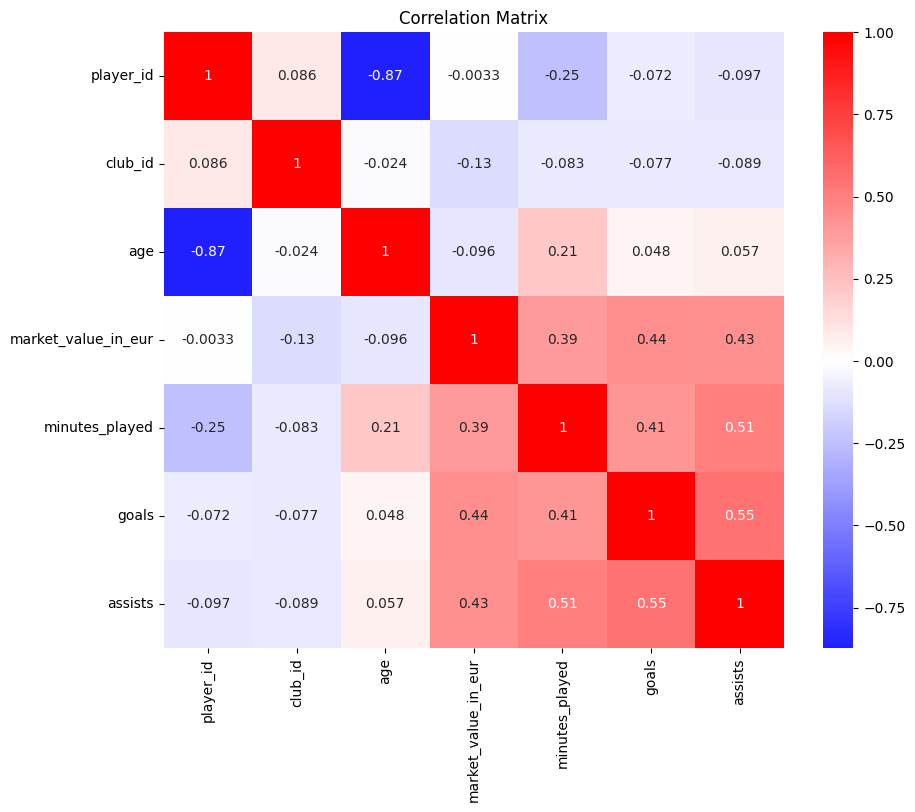

,feature_1,feature_2,correlation,absolute_correlation
2,player_id,age,-0.873335,0.873335
14,age,player_id,-0.873335,0.873335
47,assists,goals,0.550739,0.550739
41,goals,assists,0.550739,0.550739
34,minutes_played,assists,0.505441,0.505441
46,assists,minutes_played,0.505441,0.505441
26,market_value_in_eur,goals,0.443147,0.443147
38,goals,market_value_in_eur,0.443147,0.443147
27,market_value_in_eur,assists,0.432038,0.432038
45,assists,market_value_in_eur,0.432038,0.432038


In [100]:
import matplotlib.pyplot as plt

# Pearson correlation matrix
correlation_matrix = df_first_dataset.select_dtypes(include='number').corr()

# Heatmap (optional for visualization)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='bwr', center=0)
plt.title("Correlation Matrix")
plt.show()

# flatten like in the lecture
corr_df = correlation_matrix.stack().reset_index()
corr_df.columns = ['feature_1', 'feature_2', 'correlation']

# Remove self-correlations
corr_df = corr_df[corr_df['feature_1'] != corr_df['feature_2']]

# Add absolute correlation
corr_df['absolute_correlation'] = np.abs(corr_df['correlation'])

# Sort and show top 10
top_corr = corr_df.sort_values(by='absolute_correlation', ascending=False).head(10)
display(top_corr)

In [101]:
from sklearn.compose import ColumnTransformer

cat_cols = ['position']

cat_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])


In [102]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])


In [103]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='r2')
print("R2 scores:", scores)
print("Mean R2:", scores.mean())


R2 scores: [-0.34779393  0.29884156  0.2910667   0.3256589   0.09499135]
Mean R2: 0.13255291732742958
